In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

In [2]:
# Load the data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# train_df = train_df.drop(['Ticket', 'Cabin'], axis=1)
# test_df = test_df.drop(['Ticket', 'Cabin'], axis=1)

# train_df = train_df.drop(['Name', 'PassengerId'], axis=1)
# test_df = test_df.drop(['Name'], axis=1)

combine = [train_df, test_df]

In [3]:
# Enhanced feature engineering
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
for dataset in combine:
    # Create family size feature
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1
    
    # Create is_alone feature
    dataset['IsAlone'] = 1
    dataset.loc[dataset['FamilySize'] > 1, 'IsAlone'] = 0
    
    # Extract title from name
    dataset['Title'] = dataset['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    
    # Group rare titles
    rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
    dataset['Title'] = dataset['Title'].replace(rare_titles, 'Rare')
    dataset['Title'] = dataset['Title'].replace(['Mlle', 'Ms'], 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)
    
    # Extract ticket prefix and ticket length
    dataset['TicketPrefix'] = dataset['Ticket'].str.extract('([A-Za-z]+)', expand=False)
    dataset['TicketPrefix'] = dataset['TicketPrefix'].fillna('XXX')
    dataset['TicketLen'] = dataset['Ticket'].str.len()

    dataset['Age'] = pd.to_numeric(dataset['Age'], errors='coerce')
    dataset['Age'] = dataset['Age'].fillna(dataset['Age'].median())
    
    # Create age bands
    dataset['AgeBand'] = pd.cut(dataset['Age'], bins=[0, 16, 32, 48, 64, np.inf], labels=[0, 1, 2, 3, 4])
    dataset['FamilySizeCategory'] = pd.cut(dataset['FamilySize'], bins=[0, 1, 4, np.inf], labels=['Small', 'Medium', 'Large'])
    dataset['FamilySizeCategory'] = pd.Categorical(dataset['FamilySizeCategory']).codes

    
    # Create fare bands
    dataset['FareBand'] = pd.qcut(dataset['Fare'], 4)

In [4]:
# Advanced imputation
imputer = KNNImputer(n_neighbors=5)
train_df[['Age', 'Fare']] = imputer.fit_transform(train_df[['Age', 'Fare']])
test_df[['Age', 'Fare']] = imputer.transform(test_df[['Age', 'Fare']])

In [5]:
# Feature scaling
scaler = StandardScaler()
numeric_features = ['Age', 'Fare', 'FamilySize', 'TicketLen']
train_df[numeric_features] = scaler.fit_transform(train_df[numeric_features])
test_df[numeric_features] = scaler.transform(test_df[numeric_features])

In [6]:
# Encode categorical variables
categorical_features = ['Sex', 'Embarked', 'Title', 'TicketPrefix', 'AgeBand', 'FareBand']
for feature in categorical_features:
    train_df[feature] = pd.Categorical(train_df[feature]).codes
    test_df[feature] = pd.Categorical(test_df[feature]).codes

In [7]:
# for dataset in combine:
#     dataset['Age*Class'] = dataset['Age'] * dataset['Pclass']
#     dataset['Fare*Class'] = dataset['Fare'] * dataset['Pclass']
#     dataset['Age*Title'] = dataset['Age'] * dataset['Title']

In [8]:
# Feature selection
selector = SelectKBest(f_classif, k=11)
X = train_df.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'], axis=1)
y = train_df['Survived']
X_selected = selector.fit_transform(X, y)

In [9]:
X_train = train_df.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'], axis=1)
Y_train = train_df["Survived"]
X_test  = test_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1).copy()
X_train.shape, Y_train.shape, X_test.shape

((891, 15), (891,), (418, 15))

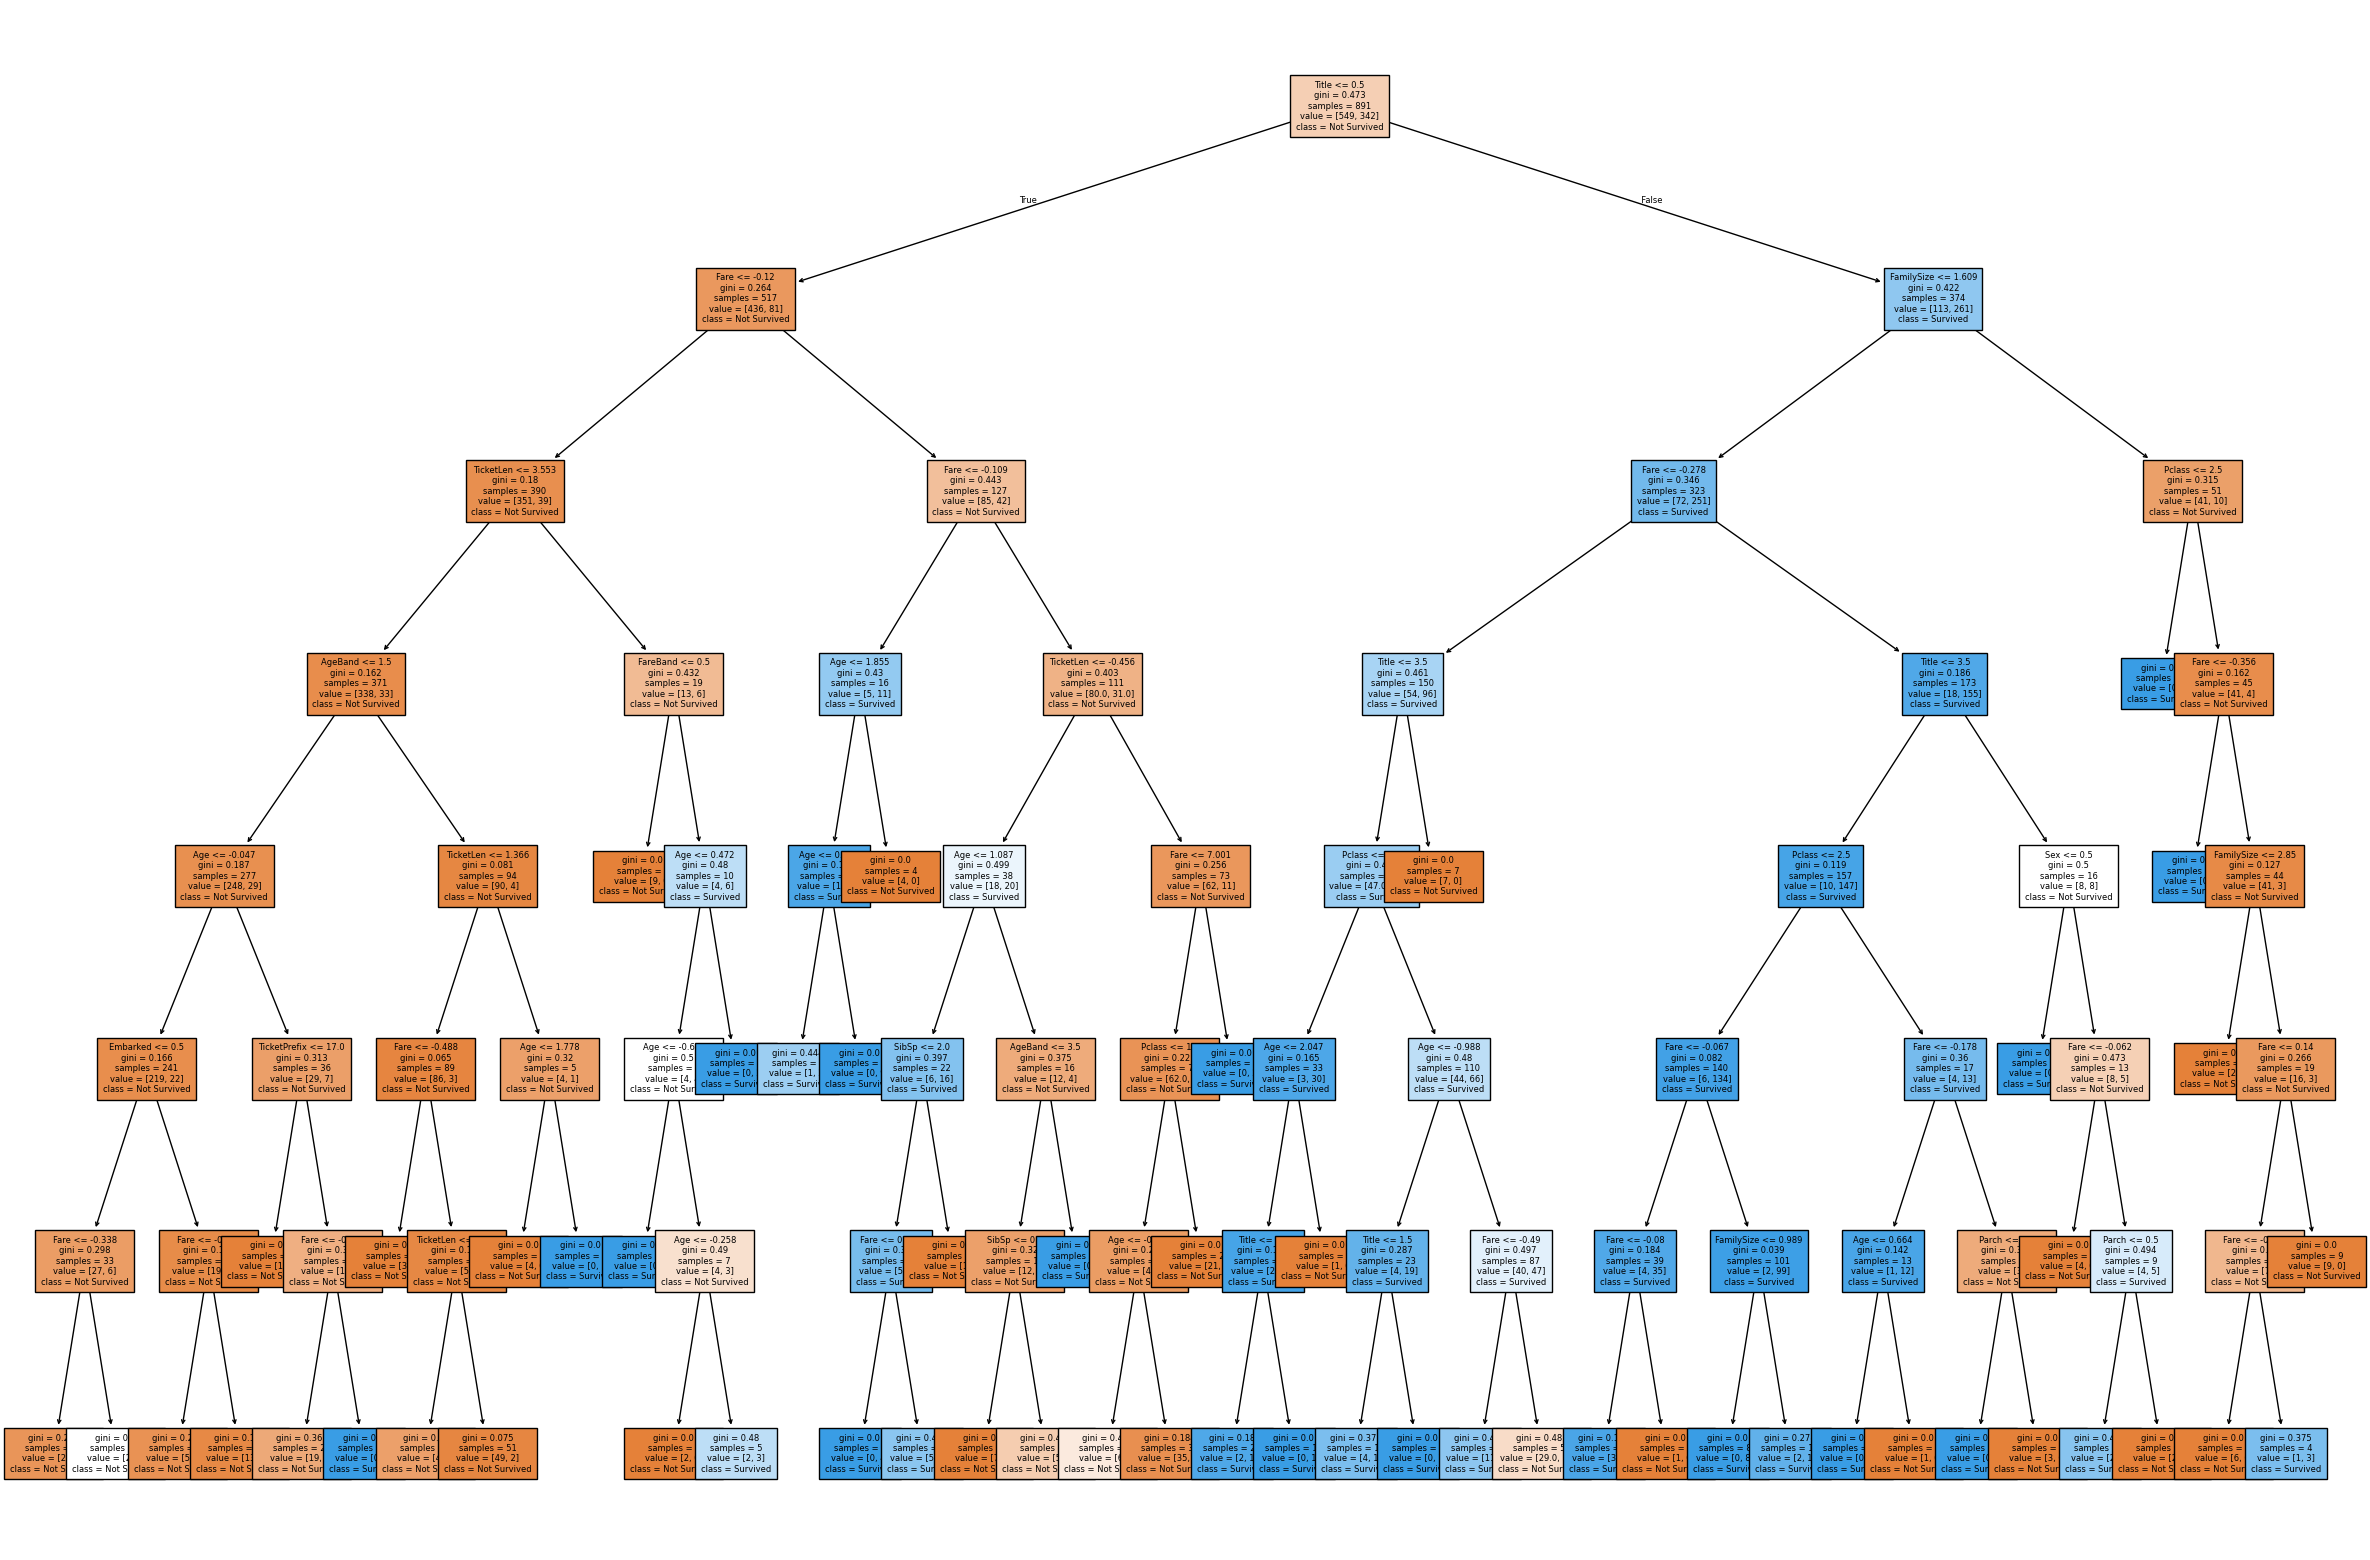

In [10]:
decision_tree = DecisionTreeClassifier(max_depth = 7)
decision_tree.fit(X_train, Y_train)

plt.figure(figsize = (30, 20))
plot_tree(decision_tree, filled = True, feature_names = X_train.columns, class_names = ["Not Survived", "Survived"], fontsize=6)
plt.show()

In [11]:
acc_scores_dt = cross_val_score(decision_tree, X_train, Y_train, cv = 5, scoring = "accuracy")
avg_acc_dt = acc_scores_dt.mean()
print(f"Average Decision Tree Classification Accuracy: {avg_acc_dt}")

Average Decision Tree Classification Accuracy: 0.8024794425961961


In [12]:
random_forest = RandomForestClassifier(n_estimators = 500, random_state = 0, max_depth = 7, n_jobs = -1)
random_forest.fit(X_train, Y_train)

RandomForestClassifier(max_depth=7, n_estimators=500, n_jobs=-1, random_state=0)

In [13]:
accuracy_scores_rf = cross_val_score(random_forest, X_train, Y_train, cv = 5, scoring = "accuracy")
avg_acc_rf = accuracy_scores_rf.mean()
print(f"Average Random Forest Classification Accuracy: {avg_acc_rf}")

Average Random Forest Classification Accuracy: 0.8327600276191074


In [14]:
models = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Score': [avg_acc_dt, avg_acc_rf]})
models.sort_values(by='Score', ascending=False)

,Model,Score
1,Random Forest,0.832760
0,Decision Tree,0.802479
